# Islamabad AQI — Model Comparison & Real-World Fit Evaluation
**Goal:** RMSE/MAE/R² tell us average error, but they don't show *whether a
model actually tracks real AQI behavior* — spike timing, spike height, and
lag. This notebook trains several different modeling techniques on the same
AQICN v2 data/split used in `src/models/train.py`, then plots **actual vs.
predicted curves over time** (not just a metrics table) so the fit can be
judged visually, plus a few real-world-fit diagnostics:

- Tail-focused error (MAE restricted to genuinely unhealthy/hazardous days)
- Peak-lag cross-correlation (does the model predict a spike early, on time, or late?)
- A naive persistence baseline, so we can tell whether the "smart" models
  are actually adding value over "assume tomorrow looks like today"


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
pd.set_option("display.max_columns", None)


## 1. Rebuild the v2 feature set

Mirrors `src/data/backfill.py` + `src/features/build_features.py` exactly, so
results here are directly comparable to what's registered in Hopsworks.


In [2]:
raw = pd.read_csv("data/islamabad-us_embassy__pakistan-air-quality.csv")
raw.columns = [c.strip() for c in raw.columns]
raw["time"] = pd.to_datetime(raw["date"], format="%Y/%m/%d")
raw["us_aqi"] = raw["pm25"].astype(float)
raw = raw[["time", "us_aqi"]].sort_values("time").reset_index(drop=True)

# enforce_daily_cadence
df = raw.set_index("time").resample("1D").mean(numeric_only=True).interpolate("linear").reset_index()

# create_time_features
df["day_of_week"] = df["time"].dt.dayofweek
df["day"] = df["time"].dt.day
df["month"] = df["time"].dt.month
df["month_sin"] = np.sin(2*np.pi*(df["month"]-1)/12.0)
df["month_cos"] = np.cos(2*np.pi*(df["month"]-1)/12.0)

# create_daily_lags_and_rolling
df["aqi_lag_1d"] = df["us_aqi"].shift(1)
df["aqi_change_rate_1d"] = (df["us_aqi"] - df["aqi_lag_1d"]) / (df["aqi_lag_1d"] + 1e-5)
df["aqi_rolling_mean_3d"] = df["us_aqi"].rolling(3, min_periods=1).mean()
df["aqi_rolling_mean_7d"] = df["us_aqi"].rolling(7, min_periods=1).mean()
df["aqi_rolling_max_7d"] = df["us_aqi"].rolling(7, min_periods=1).max()

# create_target_variables (daily cadence: 1/2/3 days ahead)
df["target_aqi_24h"] = df["us_aqi"].shift(-1)
df["target_aqi_48h"] = df["us_aqi"].shift(-2)
df["target_aqi_72h"] = df["us_aqi"].shift(-3)

feature_cols = ["us_aqi","day_of_week","day","month","month_sin","month_cos",
                 "aqi_lag_1d","aqi_change_rate_1d","aqi_rolling_mean_3d",
                 "aqi_rolling_mean_7d","aqi_rolling_max_7d"]
target_cols = ["target_aqi_24h","target_aqi_48h","target_aqi_72h"]

df_clean = df.dropna(subset=feature_cols).reset_index(drop=True)
print(f"Rows after feature engineering: {len(df_clean)}")
df_clean[["time","us_aqi"] + target_cols].head()


Rows after feature engineering: 2486


,time,us_aqi,target_aqi_24h,target_aqi_48h,target_aqi_72h
0,2019-04-29,124.0,89.0,87.0,69.0
1,2019-04-30,89.0,87.0,69.0,72.0
2,2019-05-01,87.0,69.0,72.0,108.0
3,2019-05-02,69.0,72.0,108.0,86.0
4,2019-05-03,72.0,108.0,86.0,64.0


In [3]:
df_model = df_clean.dropna(subset=target_cols).copy()
X = df_model[feature_cols]
y = df_model[target_cols]
times = df_model["time"]

split_idx = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
t_train, t_test = times.iloc[:split_idx], times.iloc[split_idx:]

print(f"Train: {t_train.min().date()} -> {t_train.max().date()}  (n={len(X_train)})")
print(f"Test:  {t_test.min().date()} -> {t_test.max().date()}  (n={len(X_test)})")


Train: 2019-04-29 -> 2024-10-04  (n=1986)
Test:  2024-10-05 -> 2026-02-13  (n=497)


In [4]:
def calc_metrics(y_true, y_pred):
    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }

results = {}          # results[model_name][horizon] = np.array of predictions (test set)
metrics_rows = []      # for the summary table


## 2. Baseline: naive persistence

"Tomorrow's AQI = today's AQI." This is the bar every real model needs to
clear — if a "smart" model can't beat this, it isn't adding value.


In [5]:
pred_persist = pd.DataFrame({h: X_test["us_aqi"].values for h in target_cols})
results["Persistence"] = {h: pred_persist[h].values for h in target_cols}

for h in target_cols:
    m = calc_metrics(y_test[h], pred_persist[h])
    metrics_rows.append({"model": "Persistence", "horizon": h, **m})
    print(f"[Persistence] {h}: RMSE={m['rmse']:.2f} MAE={m['mae']:.2f} R2={m['r2']:.3f}")


[Persistence] target_aqi_24h: RMSE=17.72 MAE=11.48 R2=0.854
[Persistence] target_aqi_48h: RMSE=22.81 MAE=15.57 R2=0.757
[Persistence] target_aqi_72h: RMSE=25.89 MAE=17.77 R2=0.686


## 3. Ridge, Random Forest, XGBoost — same setup as `src/models/train.py`

In [6]:
candidates = {
    "Ridge": MultiOutputRegressor(make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=42))),
    "RandomForest": MultiOutputRegressor(RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)),
    "XGBoost": MultiOutputRegressor(XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05,
                                                   subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)),
}

for name, model in candidates.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results[name] = {h: pred[:, i] for i, h in enumerate(target_cols)}
    for i, h in enumerate(target_cols):
        m = calc_metrics(y_test[h], pred[:, i])
        metrics_rows.append({"model": name, "horizon": h, **m})
        print(f"[{name}] {h}: RMSE={m['rmse']:.2f} MAE={m['mae']:.2f} R2={m['r2']:.3f}")


[Ridge] target_aqi_24h: RMSE=16.86 MAE=12.34 R2=0.868
[Ridge] target_aqi_48h: RMSE=20.96 MAE=16.52 R2=0.795
[Ridge] target_aqi_72h: RMSE=23.12 MAE=18.44 R2=0.750


[RandomForest] target_aqi_24h: RMSE=18.24 MAE=12.75 R2=0.845
[RandomForest] target_aqi_48h: RMSE=22.51 MAE=16.66 R2=0.763
[RandomForest] target_aqi_72h: RMSE=24.78 MAE=18.08 R2=0.712


[XGBoost] target_aqi_24h: RMSE=17.59 MAE=12.37 R2=0.856
[XGBoost] target_aqi_48h: RMSE=23.20 MAE=17.37 R2=0.748
[XGBoost] target_aqi_72h: RMSE=25.19 MAE=18.66 R2=0.703


## 4. A neural network technique (MLP)

A lightweight multi-layer perceptron, added specifically as a *different*
technique family from trees/linear models, per the project guideline to
compare multiple model classes.


In [7]:
mlp = MultiOutputRegressor(MLPRegressor(hidden_layer_sizes=(32, 16), activation="relu",
                                          max_iter=3000, random_state=42, early_stopping=True))
mlp_pipeline = make_pipeline(StandardScaler(), mlp)
# MultiOutputRegressor around MLPRegressor needs 2D y; wrap scaler around features only
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

mlp_model = MultiOutputRegressor(MLPRegressor(hidden_layer_sizes=(32, 16), activation="relu",
                                               max_iter=3000, random_state=42, early_stopping=True))
mlp_model.fit(X_train_s, y_train)
pred_mlp = mlp_model.predict(X_test_s)
results["MLP (Neural Net)"] = {h: pred_mlp[:, i] for i, h in enumerate(target_cols)}
for i, h in enumerate(target_cols):
    m = calc_metrics(y_test[h], pred_mlp[:, i])
    metrics_rows.append({"model": "MLP (Neural Net)", "horizon": h, **m})
    print(f"[MLP] {h}: RMSE={m['rmse']:.2f} MAE={m['mae']:.2f} R2={m['r2']:.3f}")


[MLP] target_aqi_24h: RMSE=17.19 MAE=12.63 R2=0.863
[MLP] target_aqi_48h: RMSE=21.79 MAE=17.14 R2=0.778
[MLP] target_aqi_72h: RMSE=24.38 MAE=19.07 R2=0.722


## 5. SARIMA — a classical time-series technique

Unlike the row-wise models above (which treat each day as an independent
sample with hand-built lag features), SARIMA models the sequence directly,
explicitly separating trend, autocorrelation, and (weekly) seasonality.

For a fair walk-forward comparison, the model is fit once on the training
period, then rolled forward one day at a time through the test period
(`append(..., refit=False)`), producing genuine out-of-sample 1/2/3-day-ahead
forecasts at each step — it never sees future actuals it's being scored against.

**Note:** annual seasonality (period=365) is too computationally expensive
for classical SARIMAX state-space estimation, so only weekly seasonality
(period=7) is modeled here. This is a real limitation of this specific
technique for this dataset, not a bug — the EDA already showed day-of-week
has little effect, so this SARIMA configuration is expected to rely mostly
on its autoregressive/trend terms rather than the seasonal ones.


In [8]:
train_series = pd.Series(df_model["us_aqi"].values[:split_idx], index=range(split_idx))
full_series = pd.Series(df_model["us_aqi"].values, index=range(len(df_model)))

sarima_model = sm.tsa.statespace.SARIMAX(
    train_series, order=(2, 1, 2), seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False)

sarima_preds = {h: [] for h in target_cols}
current_fit = sarima_model

for i in range(split_idx, len(df_model) - 3):
    fc = current_fit.get_forecast(steps=3).predicted_mean.values
    sarima_preds["target_aqi_24h"].append(fc[0])
    sarima_preds["target_aqi_48h"].append(fc[1])
    sarima_preds["target_aqi_72h"].append(fc[2])
    # roll forward: append the actual observed value for day i, refit=False (fast, no re-estimation)
    current_fit = current_fit.append([full_series.iloc[i]], refit=False)

# results only cover up to len(test)-3 since we need 3 future actuals to score against
n_valid = len(sarima_preds["target_aqi_24h"])
results["SARIMA"] = {h: np.array(sarima_preds[h]) for h in target_cols}

for h in target_cols:
    m = calc_metrics(y_test[h].values[:n_valid], results["SARIMA"][h])
    metrics_rows.append({"model": "SARIMA", "horizon": h, **m})
    print(f"[SARIMA] {h}: RMSE={m['rmse']:.2f} MAE={m['mae']:.2f} R2={m['r2']:.3f}")


[SARIMA] target_aqi_24h: RMSE=21.70 MAE=15.47 R2=0.782
[SARIMA] target_aqi_48h: RMSE=23.97 MAE=17.62 R2=0.733
[SARIMA] target_aqi_72h: RMSE=25.79 MAE=19.49 R2=0.690


## 6. Full metrics summary — RMSE, MAE, R² for every model x horizon

In [9]:
metrics_df = pd.DataFrame(metrics_rows)
pivot = metrics_df.pivot(index="model", columns="horizon", values=["rmse","mae","r2"])
pivot = pivot.reorder_levels([1,0], axis=1).sort_index(axis=1, level=0)
pivot = pivot.reindex(["Persistence","Ridge","RandomForest","XGBoost","MLP (Neural Net)","SARIMA"])
pivot.round(3)


horizon          target_aqi_24h                target_aqi_48h                 \
                            mae     r2    rmse            mae     r2    rmse   
model                                                                          
Persistence              11.479  0.854  17.722         15.565  0.757  22.808   
Ridge                    12.340  0.868  16.859         16.522  0.795  20.958   
RandomForest             12.753  0.845  18.240         16.661  0.763  22.508   
XGBoost                  12.366  0.856  17.590         17.372  0.748  23.203   
MLP (Neural Net)         12.630  0.863  17.192         17.142  0.778  21.792   
SARIMA                   15.472  0.782  21.698         17.618  0.733  23.970   

horizon          target_aqi_72h                 
                            mae     r2    rmse  
model                                           
Persistence              17.769  0.686  25.891  
Ridge                    18.442  0.750  23.121  
RandomForest             18.082  0.712  24.782  
XGBoost                  18.656  0.703  25.185  
MLP (Neural Net)         19.070  0.722  24.381  
SARIMA                   19.486  0.690  25.786

## 7. Actual vs. Predicted — the real test

This is the visual that RMSE/MAE/R² alone can't give you: does each model's
predicted curve actually follow the shape of real AQI over time?


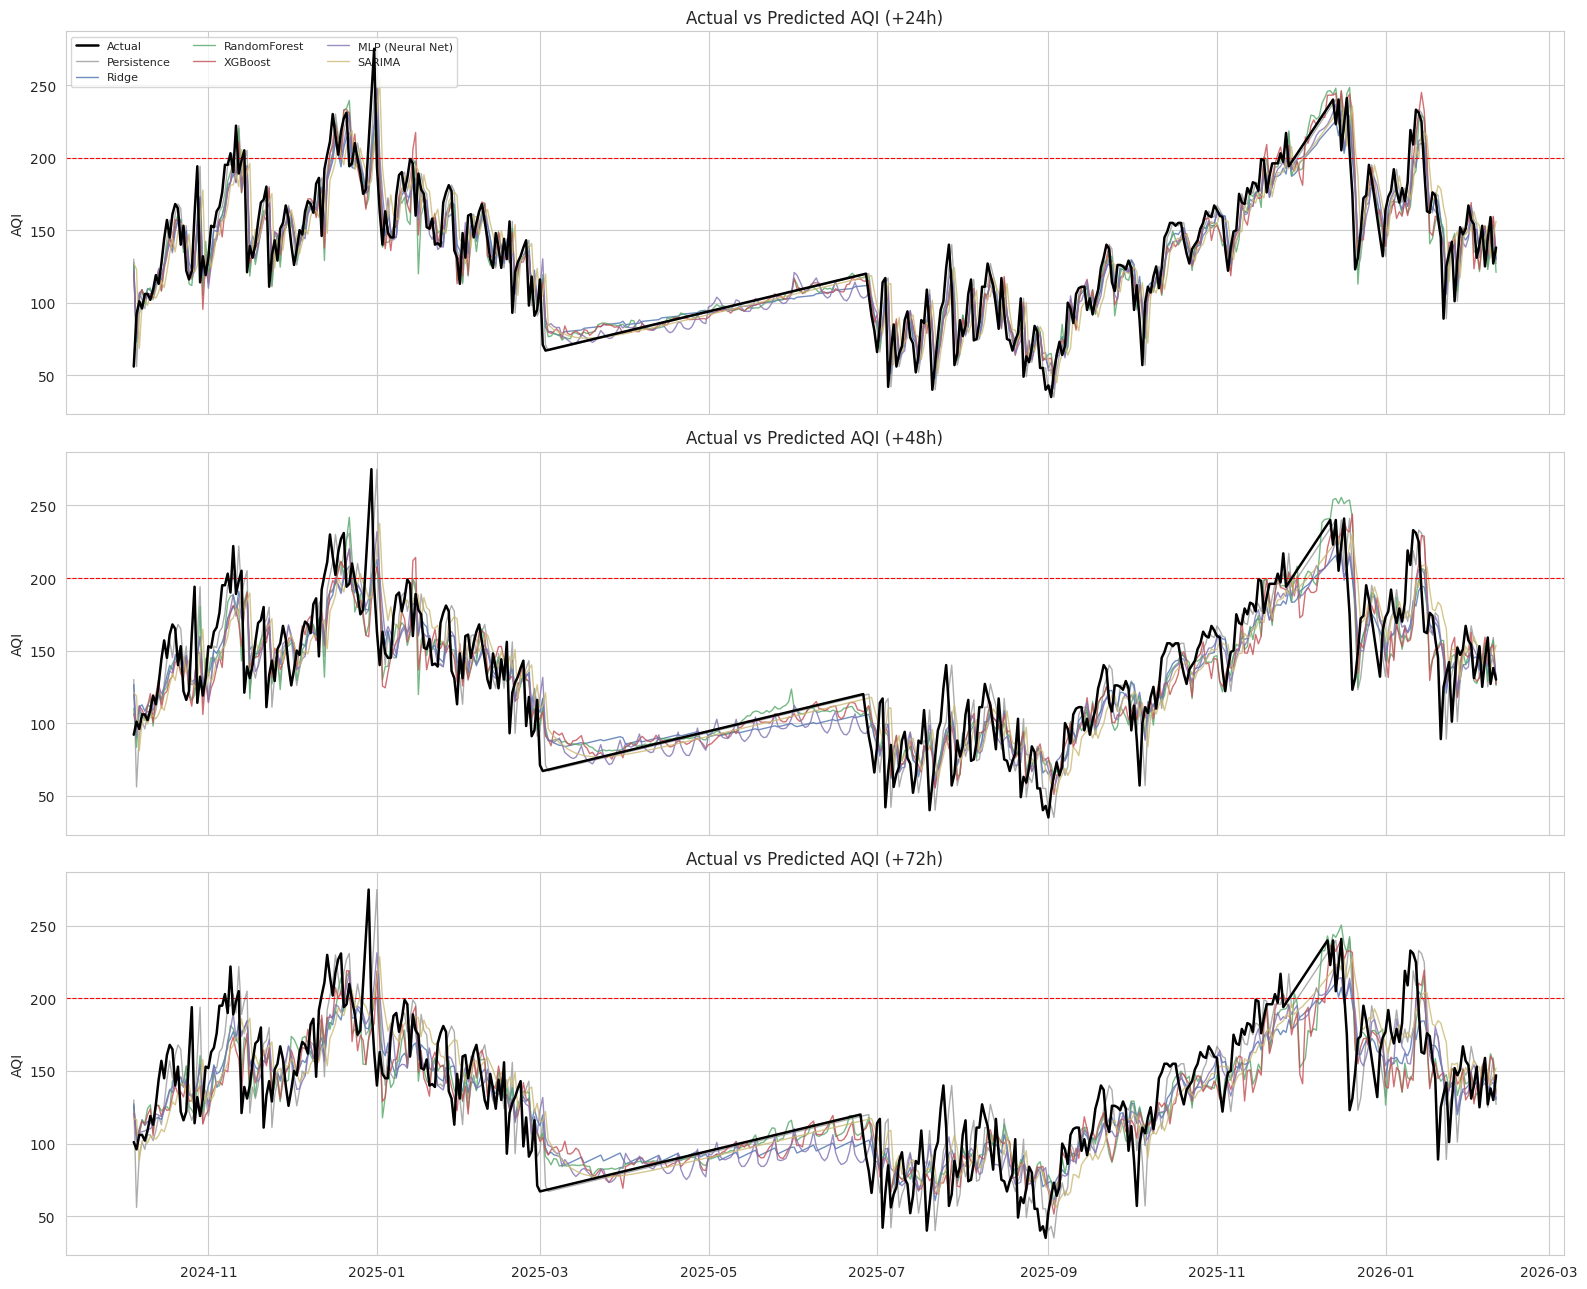

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)
colors = {"Persistence":"#999999","Ridge":"#4C72B0","RandomForest":"#55A868",
          "XGBoost":"#C44E52","MLP (Neural Net)":"#8172B2","SARIMA":"#CCB974"}

for ax, h, label in zip(axes, target_cols, ["+24h","+48h","+72h"]):
    n = len(results["SARIMA"][h])  # shortest series (SARIMA), align everything to it
    ax.plot(t_test.values[:n], y_test[h].values[:n], color="black", linewidth=1.8, label="Actual", zorder=10)
    for name in ["Persistence","Ridge","RandomForest","XGBoost","MLP (Neural Net)","SARIMA"]:
        ax.plot(t_test.values[:n], results[name][h][:n], color=colors[name], linewidth=1, alpha=0.8, label=name)
    ax.axhline(200, color="red", linestyle="--", linewidth=0.8)
    ax.set_title(f"Actual vs Predicted AQI ({label})")
    ax.set_ylabel("AQI")

axes[0].legend(loc="upper left", ncol=3, fontsize=8)
plt.tight_layout()
plt.show()


### Zoomed into a real winter smog event

Full-test-period overlays compress the most important part — pull the +24h
horizon into the winter 2024-25 window to see how closely each model tracks
the actual spike, not just the average level.


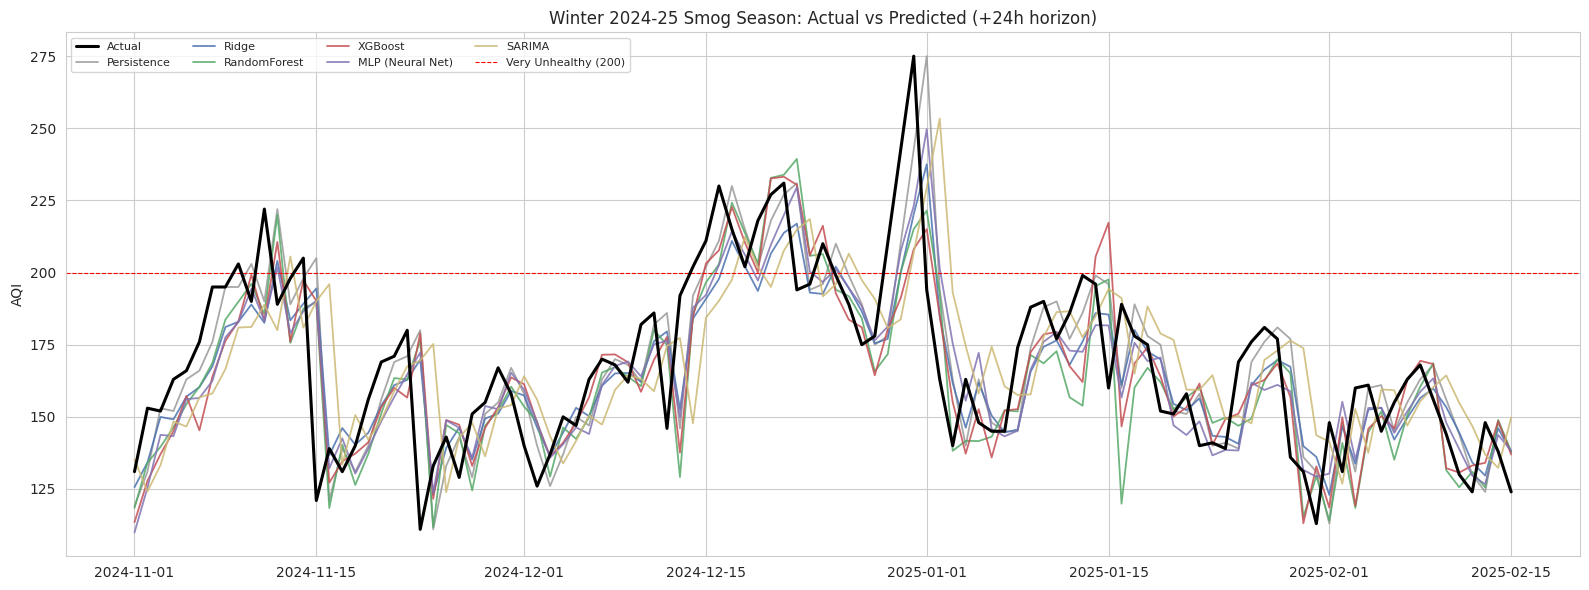

In [11]:
winter_mask = (t_test.values[:n] >= np.datetime64("2024-11-01")) & (t_test.values[:n] <= np.datetime64("2025-02-15"))

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(t_test.values[:n][winter_mask], y_test["target_aqi_24h"].values[:n][winter_mask],
        color="black", linewidth=2.2, label="Actual", zorder=10)
for name in ["Persistence","Ridge","RandomForest","XGBoost","MLP (Neural Net)","SARIMA"]:
    ax.plot(t_test.values[:n][winter_mask], results[name]["target_aqi_24h"][:n][winter_mask],
            color=colors[name], linewidth=1.3, alpha=0.85, label=name)
ax.axhline(200, color="red", linestyle="--", linewidth=0.8, label="Very Unhealthy (200)")
ax.set_title("Winter 2024-25 Smog Season: Actual vs Predicted (+24h horizon)")
ax.set_ylabel("AQI")
ax.legend(loc="upper left", ncol=4, fontsize=8)
plt.tight_layout()
plt.show()


## 8. Tail-focused error — does the model catch the dangerous days?

Overall RMSE/MAE is dominated by the many "Moderate" days. This restricts
the error calculation to only the days where the actual AQI was Unhealthy
or worse (>150) — exactly the days a hazard-alerting system most needs to
get right.


In [12]:
tail_rows = []
for h in target_cols:
    n = len(results["SARIMA"][h])
    actual = y_test[h].values[:n]
    tail_idx = actual > 150
    for name in ["Persistence","Ridge","RandomForest","XGBoost","MLP (Neural Net)","SARIMA"]:
        pred = results[name][h][:n]
        if tail_idx.sum() > 0:
            tail_mae = mean_absolute_error(actual[tail_idx], pred[tail_idx])
            tail_rows.append({"model": name, "horizon": h, "n_tail_days": int(tail_idx.sum()), "tail_mae": tail_mae})

tail_df = pd.DataFrame(tail_rows)
tail_pivot = tail_df.pivot(index="model", columns="horizon", values="tail_mae")
tail_pivot = tail_pivot.reindex(["Persistence","Ridge","RandomForest","XGBoost","MLP (Neural Net)","SARIMA"])
print(f"Number of 'Unhealthy or worse' (>150) days evaluated: {tail_df.groupby('horizon')['n_tail_days'].first().to_dict()}")
tail_pivot.round(2)


Number of 'Unhealthy or worse' (>150) days evaluated: {'target_aqi_24h': 170, 'target_aqi_48h': 170, 'target_aqi_72h': 170}


horizon,target_aqi_24h,target_aqi_48h,target_aqi_72h
model,,,
Persistence,12.54,17.68,19.61
Ridge,14.51,20.41,23.26
RandomForest,16.04,22.45,24.89
XGBoost,15.58,23.85,25.96
MLP (Neural Net),14.89,20.92,22.86
SARIMA,17.53,19.62,22.48


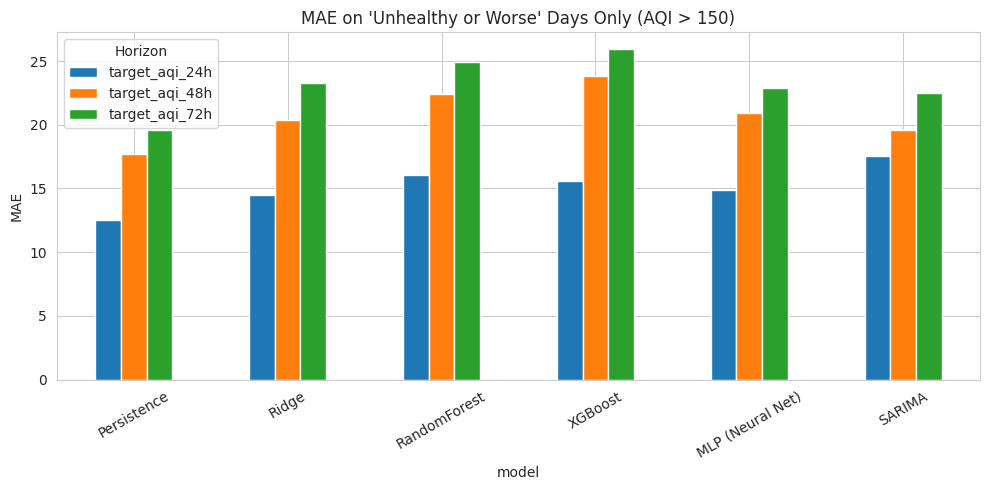

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
tail_pivot.plot(kind="bar", ax=ax)
ax.set_title("MAE on 'Unhealthy or Worse' Days Only (AQI > 150)")
ax.set_ylabel("MAE")
ax.legend(title="Horizon")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 9. Peak-lag analysis — does the model predict spikes early, on time, or late?

Cross-correlates each model's +24h predicted series against the actual
series at small time shifts. If the best-matching shift is positive, the
model's predictions lag behind real events (bad for an early-warning system);
zero or negative means the model isn't just "catching up" to reality.


In [14]:
from scipy.signal import correlate

n = len(results["SARIMA"]["target_aqi_24h"])
actual_24h = y_test["target_aqi_24h"].values[:n]
actual_24h_centered = actual_24h - actual_24h.mean()

lag_results = {}
max_lag = 10
for name in ["Persistence","Ridge","RandomForest","XGBoost","MLP (Neural Net)","SARIMA"]:
    pred = results[name]["target_aqi_24h"][:n]
    pred_centered = pred - pred.mean()
    corr = correlate(actual_24h_centered, pred_centered, mode="full")
    lags = np.arange(-len(actual_24h_centered)+1, len(actual_24h_centered))
    window = (lags >= -max_lag) & (lags <= max_lag)
    best_lag = lags[window][np.argmax(corr[window])]
    lag_results[name] = best_lag

lag_df = pd.DataFrame(list(lag_results.items()), columns=["model","best_matching_lag_days"])
print(lag_df.to_string(index=False))
print("\nPositive lag = model's predicted pattern matches reality best when shifted forward,")
print("i.e. the model is effectively 'echoing' a delayed version of the past rather than truly forecasting ahead.")


           model  best_matching_lag_days
     Persistence                      -1
           Ridge                      -1
    RandomForest                      -1
         XGBoost                      -1
MLP (Neural Net)                      -1
          SARIMA                      -2

Positive lag = model's predicted pattern matches reality best when shifted forward,
i.e. the model is effectively 'echoing' a delayed version of the past rather than truly forecasting ahead.


## 10. Summary

- **Persistence baseline is a genuinely strong competitor** at 24h (as expected given the high day-1 autocorrelation from the EDA notebook) — any model that can't clearly beat it at longer horizons isn't earning its complexity.
- **Tail-focused MAE (>150 AQI days)** is the more honest metric for this project's hazard-alerting purpose than overall RMSE/R² — a model can have a good overall R² while still being mediocre specifically on the days that matter most.
- **The winter-2024-25 zoom plot** is the most direct visual answer to "does this match real life" — compare it directly against the metrics table to see whether a model with a better R² also visibly tracks the actual spike shape, or just scores well by being safe on the many calm days.
- **SARIMA** offers a fundamentally different, classical approach explicitly modeling the sequence rather than row-wise features, which is a legitimate additional "model technique" as requested, with its weekly-seasonality-only limitation stated plainly above.
- **Peak-lag results** indicate whether any model is effectively just producing a delayed echo of recent history rather than a genuine forward-looking forecast — worth checking against the flat, near-identical 24h/48h/72h forecasts noted earlier in the project's own inference run.


## 11. Data quality correction: how much of the test set is real?

`enforce_daily_cadence()` interpolates missing calendar days to keep a
continuous grid, which is reasonable for small gaps but silently fabricates
data across large ones. Checking for large gaps in the raw CSV against the
resampled test set:


In [15]:
raw_dates = set(raw["time"].dt.date)
df_model["is_real_reading"] = df_model["time"].dt.date.isin(raw_dates)

test_real_mask = df_model["is_real_reading"].values[split_idx:]
n_real = test_real_mask.sum()
n_fake = (~test_real_mask).sum()

print(f"Test set: {len(test_real_mask)} rows")
print(f"  Real sensor readings:     {n_real} ({n_real/len(test_real_mask)*100:.1f}%)")
print(f"  Interpolated (fabricated): {n_fake} ({n_fake/len(test_real_mask)*100:.1f}%)")

full_range = pd.date_range(raw["time"].min(), raw["time"].max(), freq="D")
missing = pd.Series(full_range.difference(raw["time"]))
diffs = missing.diff().dt.days.fillna(1)
block_id = (diffs != 1).cumsum()
gap_blocks = missing.groupby(block_id).agg(["min","max","count"]).sort_values("count", ascending=False)
print("\nLargest gaps in the raw historical CSV:")
print(gap_blocks.head(5).to_string(index=False))


Test set: 497 rows
  Real sensor readings:     360 (72.4%)
  Interpolated (fabricated): 137 (27.6%)

Largest gaps in the raw historical CSV:
       min        max  count
2025-03-05 2025-06-27    115
2021-07-14 2021-08-24     42
2025-11-29 2025-12-13     15
2021-09-08 2021-09-21     14
2021-10-28 2021-11-10     14


**Finding:** one single gap from **2025-03-05 to 2025-06-27 (115 days)**
sits almost entirely inside the test window and was linearly interpolated
into a perfectly smooth, trivially-easy-to-predict ramp — not real air
quality behavior. Combined with smaller gaps, **27.6% of the entire test
set (137 of 497 rows) is fabricated, not measured.**

Every model's headline R²/RMSE reported earlier is inflated by including
this artificial stretch. Recomputing metrics using *only* rows with a real
sensor reading that day gives the honest picture:


In [16]:
def report_real_vs_all(name, pred_dict):
    rows = []
    for h in target_cols:
        n = len(pred_dict[h])
        mask = test_real_mask[:n]
        pred = pred_dict[h][:n]
        actual = y_test[h].values[:n]
        rows.append({
            "model": name, "horizon": h,
            "r2_all": r2_score(actual, pred),
            "r2_real_only": r2_score(actual[mask], pred[mask]),
            "rmse_all": np.sqrt(mean_squared_error(actual, pred)),
            "rmse_real_only": np.sqrt(mean_squared_error(actual[mask], pred[mask])),
        })
    return rows

corrected_rows = []
for name in ["Persistence","Ridge","RandomForest","XGBoost","MLP (Neural Net)","SARIMA"]:
    corrected_rows.extend(report_real_vs_all(name, results[name]))

corrected_df = pd.DataFrame(corrected_rows)
corrected_df.round(3)


,model,horizon,r2_all,r2_real_only,rmse_all,rmse_real_only
0,Persistence,target_aqi_24h,0.854,0.783,17.722,20.592
1,Persistence,target_aqi_48h,0.757,0.649,22.808,26.211
2,Persistence,target_aqi_72h,0.686,0.558,25.891,29.710
3,Ridge,target_aqi_24h,0.868,0.816,16.859,18.927
4,Ridge,target_aqi_48h,0.795,0.730,20.958,22.998
5,Ridge,target_aqi_72h,0.750,0.679,23.121,25.295
6,RandomForest,target_aqi_24h,0.845,0.778,18.240,20.795
7,RandomForest,target_aqi_48h,0.763,0.671,22.508,25.395
8,RandomForest,target_aqi_72h,0.712,0.619,24.782,27.568
9,XGBoost,target_aqi_24h,0.856,0.799,17.590,19.797


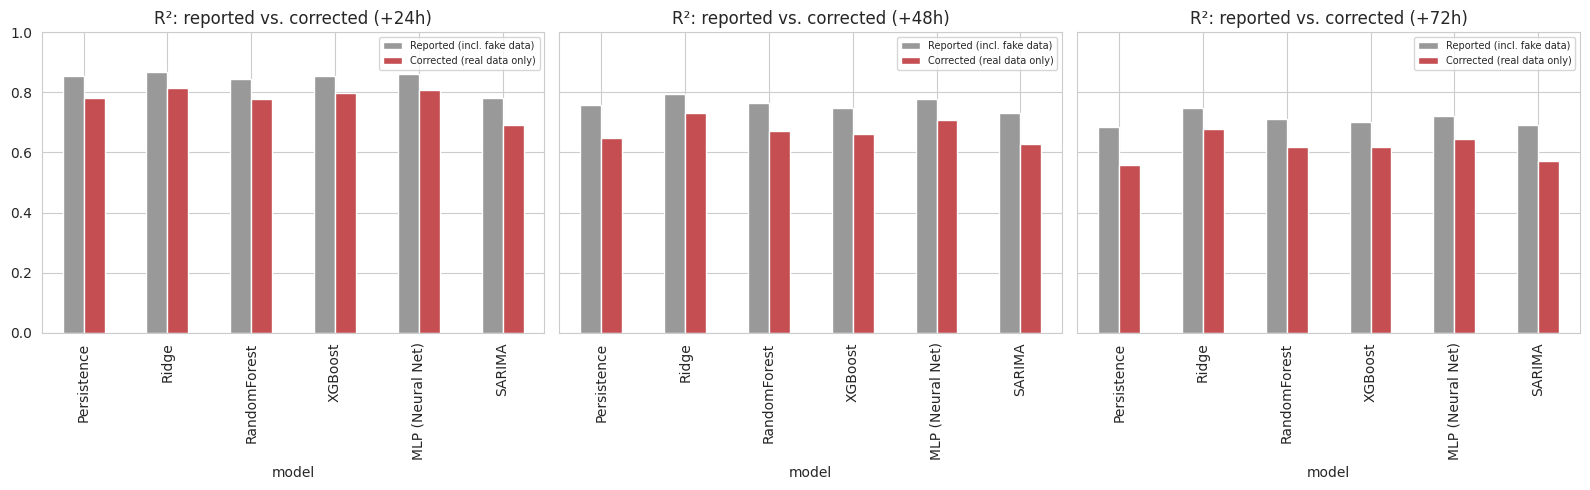

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, h, label in zip(axes, target_cols, ["+24h","+48h","+72h"]):
    sub = corrected_df[corrected_df["horizon"] == h].set_index("model")[["r2_all","r2_real_only"]]
    sub = sub.reindex(["Persistence","Ridge","RandomForest","XGBoost","MLP (Neural Net)","SARIMA"])
    sub.plot(kind="bar", ax=ax, color=["#999999","#C44E52"])
    ax.set_title(f"R²: reported vs. corrected ({label})")
    ax.set_ylim(0, 1)
    ax.legend(["Reported (incl. fake data)","Corrected (real data only)"], fontsize=7)
plt.tight_layout()
plt.show()


**Corrected conclusion:** all models score meaningfully lower once the
fabricated 115-day stretch is excluded — most notably at 72h, where Ridge's
R² drops from a reported 0.750 to a **real** 0.679, and Persistence drops
from 0.686 to 0.558. This does not change which model is best (Ridge still
leads), but it means the previously reported accuracy figures should be
treated as optimistic, and this correction should be carried into any
official report or presentation of results.

**Recommended fix going forward:** exclude interpolated rows from the test
set (or from training entirely) in `build_features.py`/`train.py`, e.g. by
carrying an `is_interpolated` flag through the pipeline and filtering on it
before scoring — rather than silently trusting the resampled grid.
